# **Features Selection - Xây dựng các đặc trưng cho mô hình**

Sau khi đã khám phá dữ liệu và những phương pháp huấn luyện mô hình đang có, trong phần này chúng tôi sẽ sàng lọc và cung cấp thêm những features quan trọng khác cho bộ dữ liệu huấn luyện của chúng tôi dựa trên đữ liệu cơ sở `base.csv`. Chúng tôi sẽ xây dựng tất cả các features có liên quan tới 2 phương pháp để dùng cho các bước sau

Cụ thể:
- Trích xuất toàn bộ dữ liệu chung hữu ích
- Xây dựng 2 bộ dữ liệu với 2 phương pháp khác nhau
- Tính toán, xây dựng các đặc trưng hữu ích cho từng bộ dữ liệu

**Mục tiêu**: Xây dựng lại tập huấn luyện với nhiều đặc trưng để cải thiện mô hình dự đoán

Mục lục:
1. [Thiết lập và cài đặt](#1)
2. [Xây dựng bộ dữ liệu cơ sở](#2)
3. [Dữ liệu cho dự đoán trực tiếp](#3)
4. [Dữ liệu cho dự đoán gián tiếp](#4)

<a id='1'></a>

## 1. Thiết lập và cài đặt

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os
sys.path.append(os.path.abspath('..'))
from src.get_data import get_connection, get_data_processed
from src.save_data import save_to_processed

In [44]:
conn = get_connection()

[OKE] Kết nối thành công tới database tại D:\datathon\vimchanhxa-datathon\data\database\datathon.duckdb


In [45]:
df_base = get_data_processed('base.csv')
df_base['date'] = pd.to_datetime(df_base['date'])
df_base.head()

Đã đọc thành công dữ liệu từ: D:\datathon\vimchanhxa-datathon\data\processed\base.csv


,date,revenue,cogs,is_test,order_count,unique_customers,total_quantity
0,2012-07-04,5123547.94,3982991.19,0,162.0,161.0,777.0
1,2012-07-05,2751773.45,2150580.23,0,97.0,97.0,428.0
2,2012-07-06,3054029.42,2517632.84,0,93.0,93.0,441.0
3,2012-07-07,2667930.94,2108246.62,0,73.0,73.0,364.0
4,2012-07-08,2360851.90,1808622.79,0,88.0,87.0,394.0


In [46]:
print(f"Train Period: {df_base[df_base['is_test'] == 0]['date'].min().date()} to {df_base[df_base['is_test'] == 0]['date'].max().date()}")
print(f"Test Period : {df_base[df_base['is_test'] == 1]['date'].min().date()} to {df_base[df_base['is_test'] == 1]['date'].max().date()}")

Train Period: 2012-07-04 to 2022-12-31
Test Period : 2023-01-01 to 2024-07-01


## 2. Xây dựng bộ feature

Trong phần này, chúng tôi sẽ trích xuất ra những features quan trọng, đặc biệt là thời gian và các dữ liệu tĩnh có tính lặp lại

### 2.1 Thời gian

In [47]:
# Đảm bảo date đúng định dạng và sắp xếp tăng dần
df_base['date'] = pd.to_datetime(df_base['date'])
df_base = df_base.sort_values('date').reset_index(drop=True)

# 1. Các biến thời gian cơ bản
df_base['month'] = df_base['date'].dt.month
df_base['day_of_month'] = df_base['date'].dt.day
df_base['day_of_week'] = df_base['date'].dt.dayofweek # 0=Thứ 2, 6=Chủ Nhật

# 2. Biến số ngày kể từ ngày bắt đầu
df_base["days_since_start"] = (df_base["date"] - df_base["date"].min()).dt.days

print("Đã tạo các biến thời gian cơ bản: month, day_of_month, day_of_week")

Đã tạo các biến thời gian cơ bản: month, day_of_month, day_of_week


### 2.2 Hệ số Seasonal index

In [48]:
# Các hệ số kỳ vọng
# 2. Ánh xạ Hệ số mùa vụ theo Năm (đã tính ở bước trước)
annual_seasonal_map = {
    1: 0.603, 2: 0.749, 3: 1.185, 4: 1.493, 5: 1.550, 6: 1.463, 
    7: 1.115, 8: 1.028, 9: 0.868, 10: 0.783, 11: 0.590, 12: 0.574
}
df_base['seasonal_index'] = df_base['month'].map(annual_seasonal_map)

# 3. Ánh xạ Hệ số kỳ vọng theo Tuần (lấy từ kết quả EDA gần nhất)
weekly_seasonal_map = {
    0: 1.026, 1: 1.039, 2: 1.057, 3: 1.023, 4: 0.938, 5: 0.918, 6: 0.971
}
df_base['day_of_week_index'] = df_base['day_of_week'].map(weekly_seasonal_map)

# 4. Hệ số kỳ vọng theo Ngày trong tháng (Ví dụ mẫu từ EDA của bạn)
# Bạn có thể thay thế bằng bảng đầy đủ 31 ngày nếu muốn chính xác tuyệt đối
df_base['intra_month_index'] = df_base.groupby('day_of_month')['revenue'].transform(lambda x: x.mean() / df_base['revenue'].mean())

print("Đã gắn các hệ số Seasonal Index thành công.")

Đã gắn các hệ số Seasonal Index thành công.


### 2.3 Sự kiện, ngày đặc biệt

In [49]:
# Các cờ nhị phân cho các ngày đặc biệt
# 5. Cờ mùa cao điểm (Tháng 3 đến tháng 8)
df_base['is_peak_season'] = df_base['month'].between(3, 8).astype(int)

# 6. Cờ cuối tuần (Thứ 7 và Chủ Nhật)
df_base['is_weekend'] = df_base['day_of_week'].isin([5, 6]).astype(int)

# 7. Cờ "Ngày hốt bạc" (Payday: 27-31 và mùng 1)
df_base['is_payday_spike'] = df_base['day_of_month'].isin([25, 26, 27, 28, 29, 30, 31, 1, 2]).astype(int)

# 8. Cờ "Ngày ế ẩm" (Hậu hóa đơn: 4-8)
df_base['is_post_bill_slump'] = df_base['day_of_month'].isin([4, 5, 6, 7]).astype(int)

df_base['is_year_end'] = ((df_base['month'] == 12) & (df_base['day_of_month'] >= 20)).astype(int)

print("Đã tạo các cờ nhị phân: is_peak_season, is_weekend, is_payday_spike, is_post_bill_slump, is_year_end")

Đã tạo các cờ nhị phân: is_peak_season, is_weekend, is_payday_spike, is_post_bill_slump, is_year_end


### 2.4 Mã giảm giá

Như ở phần `EDA`, chúng ta đã thấy rằng doanh nghiệp hiện tại đang mở các đợt giảm giá theo chu kỳ lặp lại hằng năm và hai năm. Cụ thể là với các mã giảm giá `Spring Sale`, `Mid-Year Sale`, `Fall Launch`, `Year-End Sale` đang được mở lại qua từng năm, còn với `Urban Blowout` và `Rural Special` thì lại lặp 2 năm một lần ( các năm lẻ ). Đặc biệt hơn là thời gian bắt đầu và kết thúc cũng rất khớp nhau, cùng lắm chỉ lệch 1 ngày. Tuy nhiên có một vài biến trong đó sẽ không được lặp lại giống hệt các năm trước như `min_order_value`, vì vậy dưới đây ta sẽ làm lại dữ liệu promotions này.

Do vẫn còn sự khác nhau, nên chúng tôi sẽ tạo thêm 2 cột đặc trưng để tránh bị loãng mô hình bao gồm: `is_promo` và `total_discount`, những ngày giảm giá và phần trăm đang giảm giá. Mục đích là hạn chế tạo quá nhiều cột nhiễu không cần thiết và vẫn thể hiện được sự khác biệt so với các mã giảm giá và các ngày khác. Sau đó, nếu `total_discount` không thể hiện được rõ vai trò, chúng tôi sẽ xóa đi vì trong dữ liệu sẽ có một vài mã có `stackable_flag` là không cho sử dụng 2 mã cùng lúc.

In [50]:
promotions = conn.execute("SELECT * FROM promotions").df()
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

In [51]:
# Lọc các mã giảm giá lặp lại
promo_range = pd.date_range(start=df_base["date"].min(), end=df_base["date"].max())

daily_p = pd.DataFrame({
    "date": promo_range,
    "is_promo": 0,
    "total_discount": 0.0
})

for _, row in promotions.iterrows():
    mask = (
        (daily_p["date"] >= row["start_date"]) &
        (daily_p["date"] <= row["end_date"])
    )
    daily_p.loc[mask, "is_promo"] = 1
    daily_p.loc[mask, "total_discount"] += row["discount_value"]

daily_p.head()


,date,is_promo,total_discount
0,2012-07-04,0,0.0
1,2012-07-05,0,0.0
2,2012-07-06,0,0.0
3,2012-07-07,0,0.0
4,2012-07-08,0,0.0


In [52]:
# df_base = df_base.merge(daily_p, on="date", how="left").fillna({"is_promo": 0, "total_discount": 0})
df_base = df_base.merge(daily_p, on=['date'], how='left').fillna({"is_promo": 0, "total_discount": 0})

print("Đã gắn thông tin khuyến mãi is_promo, total_discount vào thành công.")

Đã gắn thông tin khuyến mãi is_promo, total_discount vào thành công.


### 2.5 Sessions

In [53]:
sessions = conn.execute("SELECT * FROM web_traffic").df()
sessions = sessions[['date', 'sessions']]
sessions.head()

,date,sessions
0,2013-01-01,9760
1,2013-01-02,10456
2,2013-01-03,10076
3,2013-01-04,9973
4,2013-01-05,10223


In [54]:
df_base = df_base.merge(sessions, on='date', how='left')
df_base.head()

,date,revenue,cogs,is_test,order_count,unique_customers,total_quantity,month,day_of_month,day_of_week,...,day_of_week_index,intra_month_index,is_peak_season,is_weekend,is_payday_spike,is_post_bill_slump,is_year_end,is_promo,total_discount,sessions
0,2012-07-04,5123547.94,3982991.19,0,162.0,161.0,777.0,7,4,2,...,1.057,0.626209,1,0,0,1,0,0,0.0,NaN
1,2012-07-05,2751773.45,2150580.23,0,97.0,97.0,428.0,7,5,3,...,1.023,0.641836,1,0,0,1,0,0,0.0,NaN
2,2012-07-06,3054029.42,2517632.84,0,93.0,93.0,441.0,7,6,4,...,0.938,0.677476,1,0,0,1,0,0,0.0,NaN
3,2012-07-07,2667930.94,2108246.62,0,73.0,73.0,364.0,7,7,5,...,0.918,0.696571,1,1,0,1,0,0,0.0,NaN
4,2012-07-08,2360851.90,1808622.79,0,88.0,87.0,394.0,7,8,6,...,0.971,0.730281,1,1,0,0,0,0,0.0,NaN


In [55]:
# Bước 4: Tính Conversion Rate = order_count / sessions
df_base['traffic_cr'] = df_base['order_count'] / df_base['sessions']

# Tính Customer Conversion Rate = customer_count / sessions
df_base['customer_cr'] = df_base['order_count'] / df_base['unique_customers']

# Bước 5: Tính Items per Order = total_quantity / order_count
df_base['items_per_order'] = df_base['total_quantity'] / df_base['order_count']

# Tính AOV = revenue / order_count
df_base['average_order_value'] = df_base['revenue'] / df_base['order_count']

# Tính APPU = revenue / quantity
df_base['average_price_per_unit'] = df_base['revenue'] / df_base['total_quantity']

df_base.head()

,date,revenue,cogs,is_test,order_count,unique_customers,total_quantity,month,day_of_month,day_of_week,...,is_post_bill_slump,is_year_end,is_promo,total_discount,sessions,traffic_cr,customer_cr,items_per_order,average_order_value,average_price_per_unit
0,2012-07-04,5123547.94,3982991.19,0,162.0,161.0,777.0,7,4,2,...,1,0,0,0.0,NaN,NaN,1.006211,4.796296,31626.839136,6594.012793
1,2012-07-05,2751773.45,2150580.23,0,97.0,97.0,428.0,7,5,3,...,1,0,0,0.0,NaN,NaN,1.000000,4.412371,28368.798454,6429.377220
2,2012-07-06,3054029.42,2517632.84,0,93.0,93.0,441.0,7,6,4,...,1,0,0,0.0,NaN,NaN,1.000000,4.741935,32839.026022,6925.236780
3,2012-07-07,2667930.94,2108246.62,0,73.0,73.0,364.0,7,7,5,...,1,0,0,0.0,NaN,NaN,1.000000,4.986301,36546.999178,7329.480604
4,2012-07-08,2360851.90,1808622.79,0,88.0,87.0,394.0,7,8,6,...,0,0,0,0.0,NaN,NaN,1.011494,4.477273,26827.862500,5992.009898


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4380\1395297691.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2, 1].boxplot(data_to_plot, labels=metrics, patch_artist=True)


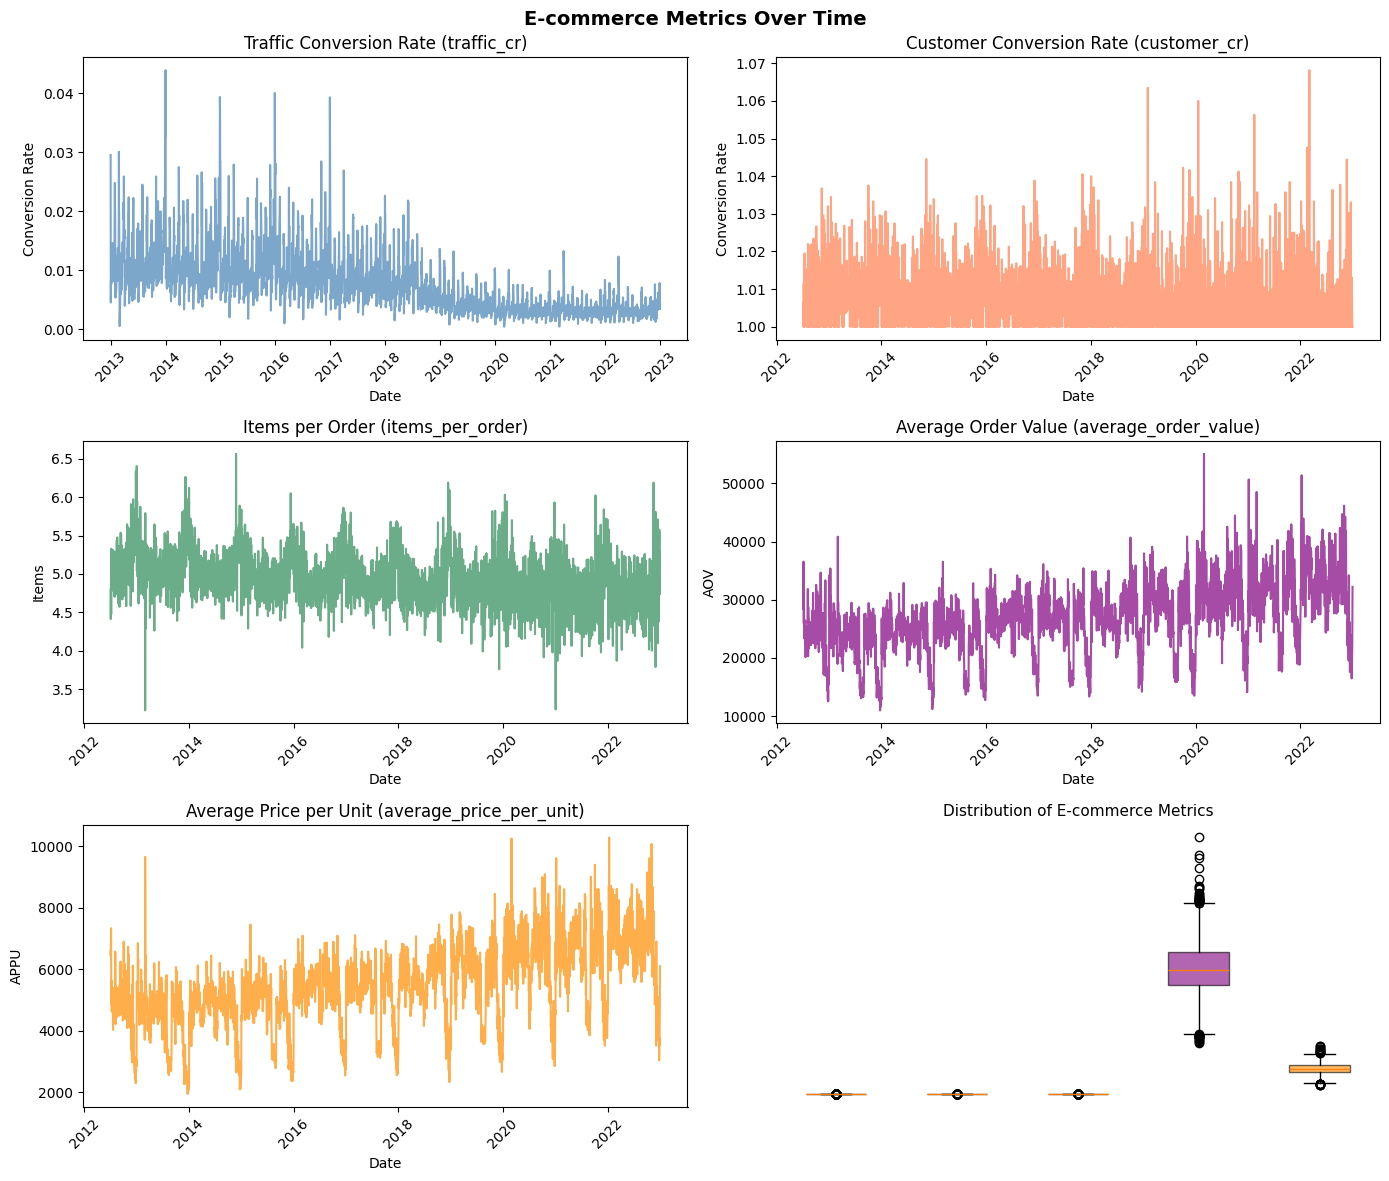


=== Summary Statistics ===
       traffic_cr  customer_cr  items_per_order  average_order_value  \
count     3652.00      3833.00          3833.00              3833.00   
mean         0.01         1.01             4.94             26754.07   
std          0.01         0.01             0.33              5765.81   
min          0.00         1.00             3.22             10983.75   
25%          0.00         1.00             4.74             23398.56   
50%          0.01         1.01             4.93             26714.65   
75%          0.01         1.01             5.12             30420.69   
max          0.04         1.07             6.56             55063.14   

       average_price_per_unit  
count                 3833.00  
mean                  5460.67  
std                   1282.47  
min                   1942.16  
25%                   4692.31  
50%                   5434.01  
75%                   6303.51  
max                  10276.45  


In [ ]:
# Visualize e-commerce features
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('E-commerce Metrics Over Time', fontsize=14, fontweight='bold')

# 1. Traffic Conversion Rate
axes[0, 0].plot(df_base['date'], df_base['traffic_cr'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Traffic Conversion Rate (traffic_cr)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Conversion Rate')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Customer Conversion Rate
axes[0, 1].plot(df_base['date'], df_base['customer_cr'], color='coral', alpha=0.7)
axes[0, 1].set_title('Customer Conversion Rate (customer_cr)')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Conversion Rate')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Items per Order
axes[1, 0].plot(df_base['date'], df_base['items_per_order'], color='seagreen', alpha=0.7)
axes[1, 0].set_title('Items per Order (items_per_order)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Items')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Average Order Value
axes[1, 1].plot(df_base['date'], df_base['average_order_value'], color='purple', alpha=0.7)
axes[1, 1].set_title('Average Order Value (average_order_value)')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('AOV')
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Average Price per Unit
axes[2, 0].plot(df_base['date'], df_base['average_price_per_unit'], color='darkorange', alpha=0.7)
axes[2, 0].set_title('Average Price per Unit (average_price_per_unit)')
axes[2, 0].set_xlabel('Date')
axes[2, 0].set_ylabel('APPU')
axes[2, 0].tick_params(axis='x', rotation=45)

# 6. Distribution comparison (boxplot)
axes[2, 1].axis('off')
metrics = ['traffic_cr', 'customer_cr', 'items_per_order', 'average_order_value', 'average_price_per_unit']
data_to_plot = [df_base[m].dropna() for m in metrics]
bp = axes[2, 1].boxplot(data_to_plot, labels=metrics, patch_artist=True)
colors = ['steelblue', 'coral', 'seagreen', 'purple', 'darkorange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[2, 1].set_title('Distribution of E-commerce Metrics', fontsize=11)
axes[2, 1].set_ylabel('Value')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Statistics summary
print("\n=== Summary Statistics ===")
print(df_base[metrics].describe().round(2))


## 3. Features cho dự đoán trực tiếp

### 3.1 Lag, Rolling

In [56]:
df_m1 = df_base.copy()
df_m1.head()

,date,revenue,cogs,is_test,order_count,unique_customers,total_quantity,month,day_of_month,day_of_week,...,is_post_bill_slump,is_year_end,is_promo,total_discount,sessions,traffic_cr,customer_cr,items_per_order,average_order_value,average_price_per_unit
0,2012-07-04,5123547.94,3982991.19,0,162.0,161.0,777.0,7,4,2,...,1,0,0,0.0,NaN,NaN,1.006211,4.796296,31626.839136,6594.012793
1,2012-07-05,2751773.45,2150580.23,0,97.0,97.0,428.0,7,5,3,...,1,0,0,0.0,NaN,NaN,1.000000,4.412371,28368.798454,6429.377220
2,2012-07-06,3054029.42,2517632.84,0,93.0,93.0,441.0,7,6,4,...,1,0,0,0.0,NaN,NaN,1.000000,4.741935,32839.026022,6925.236780
3,2012-07-07,2667930.94,2108246.62,0,73.0,73.0,364.0,7,7,5,...,1,0,0,0.0,NaN,NaN,1.000000,4.986301,36546.999178,7329.480604
4,2012-07-08,2360851.90,1808622.79,0,88.0,87.0,394.0,7,8,6,...,0,0,0,0.0,NaN,NaN,1.011494,4.477273,26827.862500,5992.009898


In [57]:
# Nhứng tháng đặc biệt có thể ảnh hưởng đến doanh thu
df_base['is_Sep_odd_year'] = (((df_base['date'].dt.month == 9) & (df_base['date'].dt.year % 2 == 1)).astype(int)).fillna(0).astype(int)
df_base['is_Dec'] = (df_base['date'].dt.month == 12).fillna(0).astype(int)
df_base['is_Jun'] = (df_base['date'].dt.month == 6).fillna(0).astype(int)

In [58]:
# Các biến lag và rolling mean cho revenue
# Nhóm biến Lag (Quá khứ xa)
df_m1['revenue_lag_7'] = (df_m1['revenue'].shift(7))
df_m1['revenue_lag_28'] = df_m1['revenue'].shift(28)
df_m1['revenue_lag_364'] = df_m1['revenue'].shift(364)

# 10. Nhóm biến Rolling (Phong độ gần đây)
# Phải shift(1) để ngày hôm nay không được nhìn thấy doanh thu của chính nó
rev_prev = df_m1['revenue'].shift(1)

df_m1['rm_lag_7'] = rev_prev.rolling(window=7).mean()
df_m1['rm_lag_28'] = rev_prev.rolling(window=28).mean()
df_m1['rm_lag_364'] = rev_prev.rolling(window=364).mean()

print("Hoàn tất tạo biến Lag, Rolling")

Hoàn tất tạo biến Lag, Rolling


### 3.2 

## 4. Features cho dự đoán gián tiếp

---
**Kết luận:**

In [ ]:
save_to_processed(df_base, "final.csv")
save_to_processed(df_m1, "final_m1.csv")

Đã lưu thành công tại: D:\datathon\vimchanhxa-datathon\data\processed\final.csv
Đã lưu thành công tại: D:\datathon\vimchanhxa-datathon\data\processed\final_m1.csv


---
**Notebooks tiếp theo:** [05_BASELINE_MODEL_.ipynb](05_BASELINE_MODEL_.ipynb) - Xây dựng mô hình cơ sở